# Notebook 06 — Single-Symbol RecurrentPPO Baseline

Architecture-validation workflow for MCB using `rl_recurrent_partition_v1`, `RecurrentPPO`, and `MlpLstmPolicy`. Learning uses TRAIN, research evaluation uses VALIDATION, and TEST remains sealed metadata-only. Nothing here promotes or registers a model.

In [1]:
from contextlib import contextmanager
import importlib.metadata
import json
from pathlib import Path
import subprocess
import sys
import tempfile

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'app.py').is_file() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
expected_python = (PROJECT_ROOT / '.venv' / 'bin' / 'python').resolve()
assert Path(sys.executable).resolve() == expected_python
versions = {name: importlib.metadata.version(name) for name in ('sb3-contrib', 'stable-baselines3', 'torch', 'gymnasium')}
commit = subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=PROJECT_ROOT, text=True).strip()
pd.DataFrame([{'Python': sys.version.split()[0], 'Executable': sys.executable, 'Git commit': commit, **versions}])

,Python,Executable,Git commit,sb3-contrib,stable-baselines3,torch,gymnasium
0,3.11.9,/Users/m.abdulbasit/Downloads/virtual-trader/....,9779484c272e3df3795db9c53779a70beed81cb6,2.9.0,2.9.0,2.13.0,1.3.0


## Contract and recurrent semantics

The first baseline uses one full TRAIN episode and one separate full VALIDATION episode. Hidden state resets at the first observation and at every real environment/symbol/window/partition boundary—not at a PPO rollout-buffer update.

In [2]:
from reinforcement_learning.recurrent_data_contract import load_recurrent_contract_metadata
from reinforcement_learning.training.recurrent_config import RecurrentPPOConfig

SYMBOL, SEED = 'MCB', 42
metadata = load_recurrent_contract_metadata(SYMBOL)
config = RecurrentPPOConfig(total_timesteps=512, seed=SEED, device='cpu')
partition_table = pd.DataFrame([
    {'Partition': 'TRAIN', 'Rows': metadata.train.rows, 'Start': metadata.train.start, 'End': metadata.train.end, 'Role': 'Learning'},
    {'Partition': 'VALIDATION', 'Rows': metadata.validation.rows, 'Start': metadata.validation.start, 'End': metadata.validation.end, 'Role': 'Research evaluation'},
    {'Partition': 'TEST', 'Rows': metadata.test.rows, 'Start': metadata.test.start, 'End': metadata.test.end, 'Role': 'SEALED METADATA ONLY'},
])
display(partition_table)
display(pd.DataFrame([config.to_dict()]).T.rename(columns={0: 'Effective value'}))
assert metadata.test.sealed and metadata.observation_shape == (17,)

,Partition,Rows,Start,End,Role
0,TRAIN,1704,2016-10-06,2023-08-23,Learning
1,VALIDATION,365,2023-08-24,2025-02-12,Research evaluation
2,TEST,366,2025-02-13,2026-08-05,SEALED METADATA ONLY


,Effective value
config_version,recurrent_ppo_single_symbol_v1
algorithm,RecurrentPPO
policy,MlpLstmPolicy
learning_rate,0.0003
n_steps,512
batch_size,64
n_epochs,10
gamma,0.99
gae_lambda,0.95
clip_range,0.2


In [3]:
@contextmanager
def sealed_test_guard():
    original = pd.read_csv
    reads = []
    def guarded(path, *args, **kwargs):
        name = Path(path).name
        reads.append(name)
        if name in {'test.csv', 'test_rl.csv'}:
            raise RuntimeError(f'SEALED TEST ACCESS: {path}')
        return original(path, *args, **kwargs)
    pd.read_csv = guarded
    try:
        yield reads
    finally:
        pd.read_csv = original

## Executed smoke training and validation

The notebook executes one 512-step recurrent run and one equal-budget MLP run in memory. The recurrent evaluator explicitly starts with `state=None`, `episode_start=True`, propagates returned LSTM state step by step, and stops after one complete VALIDATION episode.

In [4]:
from reinforcement_learning.training.recurrent_trainer import train_recurrent_single_symbol
from reinforcement_learning.training.ppo_trainer import train_single_symbol
from reinforcement_learning.training.config import PPOConfig
from reinforcement_learning.evaluation.recurrent_comparison import compare_recurrent_and_mlp_on_validation

with sealed_test_guard() as partition_reads:
    recurrent_smoke = train_recurrent_single_symbol(SYMBOL, config=config, smoke_test=True)
    mlp_smoke = train_single_symbol(SYMBOL, config=PPOConfig(total_timesteps=512, seed=SEED, device='cpu'), smoke_test=True)
    assert recurrent_smoke.succeeded, recurrent_smoke.error
    assert mlp_smoke.succeeded, mlp_smoke.error
    smoke_comparison = compare_recurrent_and_mlp_on_validation(recurrent_smoke, mlp_smoke, seed=SEED, random_seed=SEED)
assert not {'test.csv', 'test_rl.csv'}.intersection(partition_reads)
pd.DataFrame([
    {'Model': 'RecurrentPPO', 'Timesteps': recurrent_smoke.actual_timesteps, 'Parameters': recurrent_smoke.parameter_count, 'Duration seconds': recurrent_smoke.duration_seconds, 'Device': recurrent_smoke.device},
    {'Model': 'MLP PPO', 'Timesteps': mlp_smoke.actual_timesteps, 'Parameters': sum(p.numel() for p in mlp_smoke.model.policy.parameters()), 'Duration seconds': mlp_smoke.duration_seconds, 'Device': mlp_smoke.device},
])

,Model,Timesteps,Parameters,Duration seconds,Device
0,RecurrentPPO,512,51076,1.855936,cpu
1,MLP PPO,512,10884,0.524487,cpu


In [5]:
metric_names = ['final_portfolio_value', 'total_return', 'annualized_return', 'annualized_volatility', 'sharpe_ratio', 'sortino_ratio', 'maximum_drawdown', 'number_of_trades', 'total_transaction_costs', 'exposure_percentage', 'realized_profit_loss', 'final_unrealized_profit_loss']
strategies = smoke_comparison.strategies
smoke_metrics = pd.DataFrame({result.strategy: {name: result.metrics.get(name) for name in metric_names} for result in strategies}).T
display(smoke_metrics)
assert smoke_comparison.recurrent.first_episode_start
assert smoke_comparison.recurrent.episode_reset_count == 1
assert smoke_comparison.recurrent.model_parameters_unchanged
assert not smoke_comparison.test_evaluated

,final_portfolio_value,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,maximum_drawdown,number_of_trades,total_transaction_costs,exposure_percentage,realized_profit_loss,final_unrealized_profit_loss
RecurrentPPO,1.967550e+06,0.967550,0.597670,0.274172,1.846772,2.994787,0.160986,7.0,16695.759402,83.791209,1.018639e+06,-51088.028657
PPO,1.141956e+06,0.141956,0.096254,0.139857,0.725923,1.255720,0.112335,11.0,18821.375570,12.637363,1.737104e+05,-31754.281892
Buy and Hold,1.975058e+06,0.975058,0.601888,0.305134,1.697411,2.703857,0.139824,1.0,1498.198683,100.000000,0.000000e+00,975057.511317
Always Hold,1.000000e+06,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000
Random,1.706241e+06,0.706241,0.447582,0.242442,1.646593,2.823766,0.125249,124.0,245590.540009,48.351648,7.062408e+05,0.000000


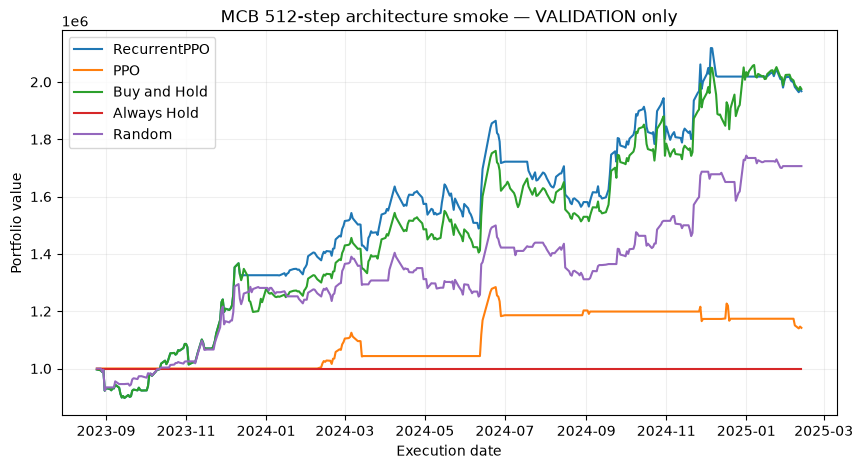

In [6]:
figure, axis = plt.subplots(figsize=(10, 5))
for result in strategies:
    history = result.history
    axis.plot(history['execution_date'], history['portfolio_value'], label=result.strategy)
axis.set_title('MCB 512-step architecture smoke — VALIDATION only')
axis.set_xlabel('Execution date'); axis.set_ylabel('Portfolio value'); axis.legend(); axis.grid(alpha=0.2)
plt.show()

## Measured isolated CPU/MPS benchmark

The benchmark was executed from the production `benchmark_recurrent_cpu_vs_mps` API in separate child processes on this commit. It used a 512-step same-device warm-up and 5,120 timed steps. It is displayed rather than repeated inside the notebook to avoid wasting another paired hardware run.

In [7]:
from reinforcement_learning.training.recurrent_benchmark import benchmark_recurrent_cpu_vs_mps
RUN_BENCHMARK_AGAIN = False
if RUN_BENCHMARK_AGAIN:
    benchmark = benchmark_recurrent_cpu_vs_mps(SYMBOL, timesteps=5_120, warmup_timesteps=512, seed=SEED)
    benchmark_rows = [benchmark.cpu.__dict__, benchmark.mps.__dict__]
else:
    benchmark_rows = [
        {'device': 'cpu', 'actual_device': 'cpu', 'actual_timesteps': 5120, 'duration_seconds': 11.080337125109509, 'timesteps_per_second': 462.07980336603686, 'status': 'completed', 'warning': None},
        {'device': 'mps', 'actual_device': 'mps:0', 'actual_timesteps': 5120, 'duration_seconds': 38.20706041599624, 'timesteps_per_second': 134.00664548001703, 'status': 'completed', 'warning': None},
    ]
display(pd.DataFrame(benchmark_rows))
print('Recommendation: CPU — approximately 3.45x faster than MPS for this recurrent workload.')

,device,actual_device,actual_timesteps,duration_seconds,timesteps_per_second,status,warning
0,cpu,cpu,5120,11.080337,462.079803,completed,None
1,mps,mps:0,5120,38.207060,134.006645,completed,None


Recommendation: CPU — approximately 3.45x faster than MPS for this recurrent workload.


## Measured 10,240-step research comparison

These measurements came from one production-API run on MCB, seed 42, CPU, with identical environment timesteps and partitions. Equal timesteps do **not** imply equal parameter counts, gradient-update compute, wall-clock time, or optimization difficulty. This one-symbol/one-seed result cannot establish that either architecture is generally better.

In [8]:
research_training = pd.DataFrame([
    {'Model': 'RecurrentPPO', 'Timesteps': 10240, 'Parameters': 51076, 'Duration seconds': 21.808821958024055, 'Rollout continuity checks': 19, 'Continuity verified': True},
    {'Model': 'MLP PPO', 'Timesteps': 10240, 'Parameters': 10884, 'Duration seconds': 5.0241924580186605, 'Rollout continuity checks': None, 'Continuity verified': None},
])
research_metrics = pd.DataFrame.from_dict({
    'RecurrentPPO': {'final_portfolio_value': 2457645.6720497627, 'total_return': 1.4576456720497628, 'sharpe_ratio': 2.5654637994027887, 'maximum_drawdown': 0.11502993593616007, 'number_of_trades': 23, 'total_transaction_costs': 66112.97795023731},
    'MLP PPO': {'final_portfolio_value': 1298314.443481863, 'total_return': 0.298314443481863, 'sharpe_ratio': 0.9469195166929569, 'maximum_drawdown': 0.10612248253921808, 'number_of_trades': 37, 'total_transaction_costs': 62929.706518137755},
    'Buy and Hold': {'final_portfolio_value': 1975057.5113168503, 'total_return': 0.9750575113168503, 'sharpe_ratio': 1.6974107734392243, 'maximum_drawdown': 0.1398235619048913, 'number_of_trades': 1, 'total_transaction_costs': 1498.198683150041},
    'Always Hold': {'final_portfolio_value': 1000000.0, 'total_return': 0.0, 'sharpe_ratio': None, 'maximum_drawdown': 0.0, 'number_of_trades': 0, 'total_transaction_costs': 0.0},
    'Random': {'final_portfolio_value': 1706240.769990664, 'total_return': 0.7062407699906639, 'sharpe_ratio': 1.6465925276198368, 'maximum_drawdown': 0.1252485346697486, 'number_of_trades': 124, 'total_transaction_costs': 245590.54000933658},
}, orient='index')
display(research_training); display(research_metrics)

,Model,Timesteps,Parameters,Duration seconds,Rollout continuity checks,Continuity verified
0,RecurrentPPO,10240,51076,21.808822,19.0,True
1,MLP PPO,10240,10884,5.024192,NaN,None


,final_portfolio_value,total_return,sharpe_ratio,maximum_drawdown,number_of_trades,total_transaction_costs
RecurrentPPO,2.457646e+06,1.457646,2.565464,0.115030,23,66112.977950
MLP PPO,1.298314e+06,0.298314,0.946920,0.106122,37,62929.706518
Buy and Hold,1.975058e+06,0.975058,1.697411,0.139824,1,1498.198683
Always Hold,1.000000e+06,0.000000,NaN,0.000000,0,0.000000
Random,1.706241e+06,0.706241,1.646593,0.125249,124,245590.540009


## Temporary save/reload proof

The recurrent zip and metadata are written outside the project, loaded with `RecurrentPPO.load` (never generic PPO), checked for architecture/state/action equality, and deleted. No registry row is created.

In [9]:
from reinforcement_learning.model_management.recurrent_persistence import verify_temporary_recurrent_round_trip
with tempfile.TemporaryDirectory(prefix='vt_notebook06_') as temporary_name:
    temporary_root = Path(temporary_name) / 'bundle'
    persistence = verify_temporary_recurrent_round_trip(recurrent_smoke, temporary_root=temporary_root)
    persistence_summary = {**persistence.__dict__, 'model_path': str(persistence.model_path), 'metadata_path': str(persistence.metadata_path)}
    assert persistence.deterministic_action_match and persistence.recurrent_state_match
deleted_root = Path(temporary_name)
assert not deleted_root.exists()
pd.DataFrame([persistence_summary])

,model_path,metadata_path,policy_class,saved_parameter_count,loaded_parameter_count,deterministic_action_match,recurrent_state_match,architecture_match,registry_touched
0,/private/var/folders/ws/57w6zv4d3zz2bbrys3dcbf...,/private/var/folders/ws/57w6zv4d3zz2bbrys3dcbf...,RecurrentActorCriticPolicy,51076,51076,True,True,True,False


## Interpretation and next step

The recurrent architecture, reset lifecycle, validation evaluator, device isolation, and temporary serialization path work. The 10,240-step outcome is not final model selection: a defensible comparison needs multiple seeds and symbols with predeclared analysis. TEST remains untouched. Sector-universe construction, TRAIN-only pooled normalization, sector pretraining, and transfer lineage belong to the next milestone.

In [10]:
final_summary = {
    'symbol': SYMBOL, 'seed': SEED, 'recurrent_trainer': recurrent_smoke.trainer_version,
    'recurrent_contract': recurrent_smoke.recurrent_contract_version, 'environment': recurrent_smoke.environment_version,
    'smoke_timesteps': recurrent_smoke.actual_timesteps, 'validation_rows': smoke_comparison.recurrent.validation_rows,
    'recurrent_state_propagated': smoke_comparison.recurrent.recurrent_state_steps > 0,
    'TEST frame reads': 0, 'production_registry_writes': 0, 'production_models_promoted': 0,
}
pd.DataFrame([final_summary])

,symbol,seed,recurrent_trainer,recurrent_contract,environment,smoke_timesteps,validation_rows,recurrent_state_propagated,TEST frame reads,production_registry_writes,production_models_promoted
0,MCB,42,recurrent_ppo_single_symbol_v1,rl_recurrent_partition_v1,single_symbol_env_v1,512,365,True,0,0,0
